In [2]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [3]:
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        vec_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div

            make_vec_dim = np.ones(temp[1])
            make_vec_dim *= np.abs(np.sqrt(div))
            
            sys_gibbs.append(make_matrix_dim)
            vec_gibbs.append(make_vec_dim)

            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == 1:
            return ret_matrix
        if TF == 0:
            return sys_gibbs
        if TF == 2:
            return vec_gibbs

    else:
        print("Not available input source")
        return None

In [4]:
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([4,5,3])

In [5]:
Cal_Gibbs_T = degen_Gibbs_create(Gibbs,degeneracy,0)
Cal_Gibbs_V = degen_Gibbs_create(Gibbs,degeneracy,2)

In [9]:
asdf = coherent_dm(2,-0.4j)
Sys_block = asdf.full()

pointz

0.6967067093471656

In [11]:
gamma = np.sqrt(Sys_block[0][0]*Sys_block[1][1])
ele1 = Sys_block[0][0] - Sys_block[1][1]
ele2 = Sys_block[0][0] + Sys_block[1][1] -1

pointx = expect(sigmax(), asdf)
pointy = expect(sigmay(), asdf)
pointz = expect(sigmaz(), asdf)

Bloc_map = Qobj([[1,0,0,0],[0,np.exp(-10/5),0,0],[0,0,np.exp(-10/5),0],[(1-np.exp(-10/3))*0.5,0,0,np.exp(-10/3)]])
point_vec = Qobj([1,pointx,pointy,pointz])

point_vec = Bloc_map * point_vec

point_vec1 = Bloc_map * point_vec
point_vec2 = Bloc_map * point_vec1
point_vec3 = Bloc_map * point_vec2
point_vec4 = Bloc_map * point_vec3
point_vec5 = Bloc_map * point_vec4
point_vec6 = Bloc_map * point_vec5

In [10]:
asdf

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.848+0.j     0.000+0.359j]
 [ 0.000-0.359j  0.152+0.j   ]]

In [96]:
point_vec8 = Bloc_map * point_vec7

In [ ]:
point_vec4

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[  1.000e+00]
 [  0.000e+00]
 [ -3.257e-05]
 [  5.000e-01]]

: 

In [ ]:
point_collec = Qobj([point_vec[1],point_vec[2],point_vec[3]]

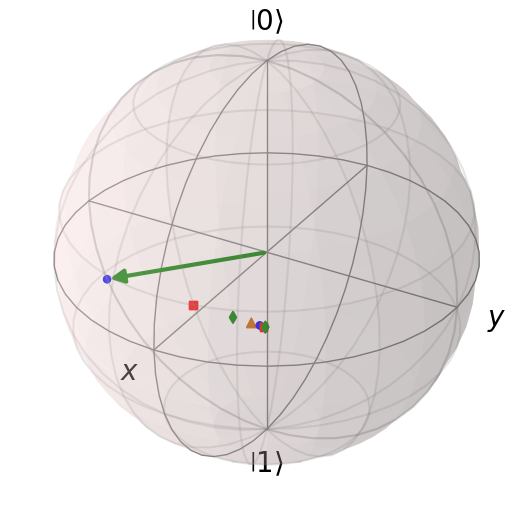

In [102]:
b = Bloch()

b.add_points([pointx, pointy, pointz])
b.add_vectors([pointx, pointy, pointz])
b.add_points([point_vec[1][0],point_vec[2][0],point_vec[3][0]])
#b.add_vectors([point_vec[1][0],point_vec[2][0],point_vec[3][0]])

b.add_points([point_vec1[1][0],point_vec1[2][0],point_vec1[3][0]])
#b.add_vectors([point_vec1[1][0],point_vec1[2][0],point_vec1[3][0]])

b.add_points([point_vec2[1][0],point_vec2[2][0],point_vec2[3][0]])
#b.add_vectors([point_vec2[1][0],point_vec2[2][0],point_vec2[3][0]])

b.add_points([point_vec3[1][0],point_vec3[2][0],point_vec3[3][0]])
#b.add_vectors([point_vec3[1][0],point_vec3[2][0],point_vec3[3][0]])

b.add_points([point_vec4[1][0],point_vec4[2][0],point_vec4[3][0]])
#b.add_vectors([point_vec4[1][0],point_vec4[2][0],point_vec4[3][0]])

b.add_points([point_vec5[1][0],point_vec5[2][0],point_vec5[3][0]])

b.show()